# Week 2 EDA: Win Rates, Time, and Leakage

In Week 1, we reshaped the League of Legends dataset from one row per game to one row per player-game. In this notebook, we use that thin table to understand the data before building features or training a model.

The goal is not to maximize predictive accuracy yet. The goal is to answer:

1. What does the dataset contain?
2. How does win rate vary across meaningful groups?
3. Which patterns look stable, and which may be noise?
4. What information would be available before a match starts?
5. Which EDA summaries would become leakage if used as model features?

Throughout the notebook, every grouped win-rate table should include both `win_rate` and `n`, because a win rate without sample size is easy to overinterpret.

In [1]:
import pandas as pd
from pathlib import Path

from huggingface_hub import HfApi
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
import glob

drive.mount('/content/drive')

from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id="rubiogarciaf/DSCI6523_LeagueofLegends",
    repo_type="dataset",
    local_dir="/content/drive/MyDrive/newman_ml_ops/data_huggingface_new" # Updated to the specified Google Drive path
)
print(f"Downloaded to {local_dir}")

df = pd.read_parquet(glob.glob(local_dir + "/*.parquet"))

df.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 34 files:   0%|          | 0/34 [00:00<?, ?it/s]

Downloaded to /content/drive/MyDrive/newman_ml_ops/data_huggingface_new


,gameId,gameCreation,gameCreationDate,gameDuration,patch,tier,average_leaguePoints,bwin,b1_puuid,b1_teamPosition,...,r4_puuid,r4_teamPosition,r4_championId,r4_leaguePoints,r4_mpoints,r5_puuid,r5_teamPosition,r5_championId,r5_leaguePoints,r5_mpoints
0,5554887388,1778112012000,05/07/2026,1628,169,Bronze I,747.4,1,aIo-ehCfVztnixyhx_moFpzMFWCLYxAhDEf1PbUsbh-c_i...,TOP,...,QcYwM6qKMADC5r1_blhy8mq0_6NimMo_ddwFOHP9GHzeqB...,BOTTOM,804,901.0,23050.0,8RbPWKWQ5C-GauAK4rIs9TPEc3__JQzW7x7wQGgt8OQNAE...,UTILITY,117,698.0,56880.0
1,5554889227,1778112280000,05/07/2026,2073,169,Bronze I,724.8,0,DCxZCI9BawhcsYQEVH1hS6YqVS8jsjqTJiRAXTl-EWYnx8...,TOP,...,et3CI2OBH2SyFGoPBFl508ashVgZWFnCbQHmIFcKS4FoGs...,BOTTOM,51,608.0,198145.0,j2E6If153AMjHwAy6oAiNWmwkrtS5eEfJEXqVIiJVfr4U8...,UTILITY,902,917.0,1305.0
2,5554889599,1778112328000,05/07/2026,1865,169,Bronze I,725.7,0,y2f--nrfSidXf2XE_nzu2NUGuiwp-COxga6J6Jxsf1MAZa...,TOP,...,xLK9nrYIjkJw3G3QjMtoB-VOX6eSi711IKQNVC7-jpv-cM...,BOTTOM,51,671.0,25955.0,QPu2gO5XbyNIvnrTRdoYgG7Tioz6C__ICrvs4sVYy4yGua...,UTILITY,17,829.0,1860657.0
3,5554891355,1778112259000,05/07/2026,2476,169,Bronze I,789.6,1,eEW6Y0mUP7dMcbh-Nk7HfpQWg1RvTTrDfTa0YxhYFdQg3I...,TOP,...,SSsJyr19SnVu_ysQsvbikTWqBAKIYlsdoUnpFNGNia-m_R...,BOTTOM,360,771.0,298294.0,hRttrpbPj9bOwupzVhfLhjoEby0GgGB05Ap-ajBMinvT_d...,UTILITY,202,820.0,7975.0
4,5554893781,1778112396000,05/07/2026,1905,169,Bronze I,773.9,1,RKeHIRhaIvutH1wlzHYH8DS2rftsYynj0ifkW9tbCud67r...,TOP,...,fl3iEO_6sJZBw1wNfxo8-NccboHcwAbl0sZQScZtprEoR0...,BOTTOM,96,748.0,290659.0,oxmLsiDFyxoU4FpAGCrnGRG6jalrbozxEpb9M9IOvQrc1o...,UTILITY,267,832.0,24282.0


# Download Dataframe from Hugging Face

In [3]:
# Don't run this cell as contents replaced by cell above
'''
api = HfApi()
files = api.list_repo_files(
    repo_id="rubiogarciaf/DSCI6523_LeagueofLegends",
    repo_type="dataset"
)
parquet_files = [f for f in files if f.endswith(".parquet")]

base = "https://huggingface.co/datasets/rubiogarciaf/DSCI6523_LeagueofLegends/resolve/main"
df = pd.concat(
    [pd.read_parquet(f"{base}/{f}") for f in parquet_files],
    ignore_index=True
)
df.head(5)
'''

'\napi = HfApi()\nfiles = api.list_repo_files(\n    repo_id="rubiogarciaf/DSCI6523_LeagueofLegends",\n    repo_type="dataset"\n)\nparquet_files = [f for f in files if f.endswith(".parquet")]\n\nbase = "https://huggingface.co/datasets/rubiogarciaf/DSCI6523_LeagueofLegends/resolve/main"\ndf = pd.concat(\n    [pd.read_parquet(f"{base}/{f}") for f in parquet_files],\n    ignore_index=True\n)\ndf.head(5)\n'

# Make Dataset Thin

In [4]:
def make_thin(df):
    # Game-level columns that apply to every player in the game
    game_cols = [
        "gameId",
        "gameCreation",
        "gameCreationDate",
        "gameDuration",
        "patch",
        "tier",
        "average_leaguePoints",
        "bwin"
    ]

    player_features = [
        "puuid",
        "teamPosition",
        "championId",
        "leaguePoints",
        "mpoints"
    ]

    slots = ["b1", "b2", "b3", "b4", "b5", "r1", "r2", "r3", "r4", "r5"]

    thin_parts = []

    for slot in slots:
        temp = df[game_cols].copy()

        # Identify where this player came from in the wide table
        temp["player_slot"] = slot
        temp["team"] = "blue" if slot.startswith("b") else "red"
        temp["team_player_number"] = int(slot[1])

        # Pull this player's columns and remove the b1_, r3_, etc. prefix
        for feature in player_features:
            temp[feature] = df[f"{slot}_{feature}"]

        # Correct player-level outcome
        # bwin = 1 means blue team won
        # red players won when bwin = 0
        temp["win"] = temp["bwin"] if slot.startswith("b") else 1 - temp["bwin"]

        thin_parts.append(temp)

    thin = pd.concat(thin_parts, ignore_index=True)

    # Drop game-level blue-win outcome after using it to build player-level win
    thin = thin.drop(columns=["bwin"])

    # Optional: nice column order
    thin = thin[
        [
            "gameId",
            "gameCreation",
            "gameCreationDate",
            "gameDuration",
            "patch",
            "tier",
            "average_leaguePoints",
            "player_slot",
            "team",
            "team_player_number",
            "puuid",
            "teamPosition",
            "championId",
            "leaguePoints",
            "mpoints",
            "win"
        ]
    ]
    thin = thin.sort_values(by=['gameId','player_slot'],ascending=False)

    return thin

In [5]:
thin_df = make_thin(df)
del df #Release Memory!
thin_df.head(20)

,gameId,gameCreation,gameCreationDate,gameDuration,patch,tier,average_leaguePoints,player_slot,team,team_player_number,puuid,teamPosition,championId,leaguePoints,mpoints,win
9094967,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,r5,red,5,wjxSxTfZG1Rtk6n8MwDnOv1PTsZqRcPeDUBBvqlXVwFmuV...,UTILITY,235,1421.0,143459.0,1
8182711,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,r4,red,4,4MgBjw7f7_Tu7y_vdZeOSWgkzhAsLlwm-3EZGln_0cD011...,BOTTOM,22,1915.0,532067.0,1
7270455,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,r3,red,3,YJG8CsyRbaJVRW9lIO48qgVEeVHyAtGMXUYEiib8dpDfEp...,MIDDLE,4,1670.0,114398.0,1
6358199,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,r2,red,2,U7vZzs2DZxxZQs-Zk6A9qnpMzpIJOcobAaHFtBoY4KHqCQ...,JUNGLE,131,1784.0,96035.0,1
5445943,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,r1,red,1,mhPeHjh6XSbWblLw9FlkfrcsCsDlZ80JoxTLbTNdg25Tg8...,TOP,114,1772.0,129804.0,1
4533687,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,b5,blue,5,diEsi7kv2s5XBP9LuGVYK9Ui_LfUVYb0XKl72SR35066Ry...,UTILITY,111,1731.0,59683.0,0
3621431,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,b4,blue,4,oBM3CDI2QtlZR5gNpamG_z-3i4KR06JF5E05KVCC5M67rd...,BOTTOM,81,1745.0,9090.0,0
2709175,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,b3,blue,3,2OAnNGHE9QHkf-vAF3YXqB31OCXXXOSYUsSWFlrk-VsIYh...,MIDDLE,34,1731.0,123186.0,0
1796919,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,b2,blue,2,898-PSZPi0WTSBcGB2tHVx8Yy3nNJ5lhXHb8xiRpFelnxz...,JUNGLE,234,1701.0,131338.0,0
884663,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,b1,blue,1,DTp44hQQIX_7EHQG53lsvhMqOHOaEGrp6UiQaJxr8kz30t...,TOP,54,1717.0,13017.0,0


In [6]:
thin_df.sort_values(by=['gameId','player_slot'], ascending=False).head(10)

,gameId,gameCreation,gameCreationDate,gameDuration,patch,tier,average_leaguePoints,player_slot,team,team_player_number,puuid,teamPosition,championId,leaguePoints,mpoints,win
9094967,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,r5,red,5,wjxSxTfZG1Rtk6n8MwDnOv1PTsZqRcPeDUBBvqlXVwFmuV...,UTILITY,235,1421.0,143459.0,1
8182711,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,r4,red,4,4MgBjw7f7_Tu7y_vdZeOSWgkzhAsLlwm-3EZGln_0cD011...,BOTTOM,22,1915.0,532067.0,1
7270455,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,r3,red,3,YJG8CsyRbaJVRW9lIO48qgVEeVHyAtGMXUYEiib8dpDfEp...,MIDDLE,4,1670.0,114398.0,1
6358199,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,r2,red,2,U7vZzs2DZxxZQs-Zk6A9qnpMzpIJOcobAaHFtBoY4KHqCQ...,JUNGLE,131,1784.0,96035.0,1
5445943,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,r1,red,1,mhPeHjh6XSbWblLw9FlkfrcsCsDlZ80JoxTLbTNdg25Tg8...,TOP,114,1772.0,129804.0,1
4533687,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,b5,blue,5,diEsi7kv2s5XBP9LuGVYK9Ui_LfUVYb0XKl72SR35066Ry...,UTILITY,111,1731.0,59683.0,0
3621431,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,b4,blue,4,oBM3CDI2QtlZR5gNpamG_z-3i4KR06JF5E05KVCC5M67rd...,BOTTOM,81,1745.0,9090.0,0
2709175,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,b3,blue,3,2OAnNGHE9QHkf-vAF3YXqB31OCXXXOSYUsSWFlrk-VsIYh...,MIDDLE,34,1731.0,123186.0,0
1796919,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,b2,blue,2,898-PSZPi0WTSBcGB2tHVx8Yy3nNJ5lhXHb8xiRpFelnxz...,JUNGLE,234,1701.0,131338.0,0
884663,5572416279,1780271018000,05/31/2026,960,1611,Emerald III,1718.7,b1,blue,1,DTp44hQQIX_7EHQG53lsvhMqOHOaEGrp6UiQaJxr8kz30t...,TOP,54,1717.0,13017.0,0


# Understanding our Data

In [7]:
thin_df.shape

(9122560, 16)

In [8]:
thin_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9122560 entries, 9094967 to 144123
Data columns (total 16 columns):
 #   Column                Dtype  
---  ------                -----  
 0   gameId                int64  
 1   gameCreation          int64  
 2   gameCreationDate      object 
 3   gameDuration          int64  
 4   patch                 int64  
 5   tier                  object 
 6   average_leaguePoints  float64
 7   player_slot           object 
 8   team                  object 
 9   team_player_number    int64  
 10  puuid                 object 
 11  teamPosition          object 
 12  championId            int64  
 13  leaguePoints          float64
 14  mpoints               float64
 15  win                   int64  
dtypes: float64(3), int64(7), object(6)
memory usage: 1.2+ GB


In [9]:
thin_df.isna().mean().sort_values(ascending=False)

,0
gameId,0.0
gameCreation,0.0
gameCreationDate,0.0
gameDuration,0.0
patch,0.0
tier,0.0
average_leaguePoints,0.0
player_slot,0.0
team,0.0
team_player_number,0.0


In [10]:
thin_df["gameId"].nunique()

912256

In [11]:
thin_df["championId"].nunique()

172

In [12]:
thin_df["puuid"].nunique()

600304

## Creating a Game-Level Table from the Thin Table

The thin table has one row per player-game, so each match appears ten times. That is useful for player-level EDA, but it is not appropriate when we want to count games or compute game-level win rates.

For game-level summaries, we first create `first_rows`, which keeps one row per `gameId`.

Because the first player row is from the blue team in our reshape, the player-level `win` value on that first row is equivalent to `bwin`: whether the blue team won.

This table should be used for game-level questions such as:

- games per date
- games per patch
- blue-side win rate
- average game duration
- win rate by tier or patch

In [13]:
first_rows = thin_df.groupby("gameId").first().reset_index()
first_rows.head(5)

,gameId,gameCreation,gameCreationDate,gameDuration,patch,tier,average_leaguePoints,player_slot,team,team_player_number,puuid,teamPosition,championId,leaguePoints,mpoints,win
0,5550784554,1777593745000,05/01/2026,2038,169,Silver II,1074.4,r5,red,5,RKJaP7SdHKz2ZejrwTV9cgx6GW3hfERG1ObA073fAE97MY...,UTILITY,800,850.0,5338.0,0
1,5550784663,1777593610000,05/01/2026,1389,169,Platinum II,2295.2,r5,red,5,w3DeAihb_UkZhByKgFnFKuFauAfQ0lFMswK2sbUaEVuaeQ...,UTILITY,37,2201.0,936162.0,1
2,5550784708,1777593772000,05/01/2026,2060,169,Silver II,1087.8,r5,red,5,YaOZebCeLfGUAJk4uwxklUc-nYQipeBNmWr0dlJUWoqMXP...,UTILITY,50,1113.0,84407.0,1
3,5550785582,1777593709000,05/01/2026,1938,169,Bronze IV,453.9,r5,red,5,ub7gOB_ClGaCF-wAACnm3LYCP4cwpBXF_Nn244gyowp-37...,UTILITY,555,382.0,99930.0,0
4,5550785626,1777593639000,05/01/2026,1228,169,Emerald III,1783.7,r5,red,5,utvlLrJgWy3xG6n8HvoamqDLv4IhUEuv1XWRsuLCqe_1rA...,UTILITY,201,2074.0,81943.0,0


### Verification

The table `first_rows` should have exactly one row per game. This matters because using the full thin table would count each game ten times.

This check protects us from accidentally reporting player-row counts as game counts.

In [14]:
print(first_rows["gameId"].nunique())
print(len(first_rows))

912256
912256


## Baseline Blue-Side Win Rate

The first baseline is the overall blue-side win rate. This gives us a simple reference point for later comparisons.

If blue side wins about 50% of the time, then any model or grouped pattern needs to be interpreted relative to that baseline. A group with a 51% win rate may be statistically real with enough data, but it may not be practically meaningful.

In [15]:
win_rate_baseline = float(round(first_rows["win"].mean(),4)*100)
print(f"Blue team wins {win_rate_baseline}% of the games")

Blue team wins 50.51% of the games


## Champion Win Rate

This table summarizes how often each champion wins across all player-game rows.

The important columns are:

- `Games`: how many times the champion appears
- `Wins`: how many of those appearances resulted in a win
- `Win Rate`: wins divided by games

In [16]:
out = (
    thin_df.groupby(['championId'])
    .agg(
        games=('win', "size"),
        wins=('win', "sum"),
        win_rate=('win', "mean")
    )
    .reset_index()
)
out['win_rate'] = (round(out['win_rate'],4)*100).astype(float)
out.columns = ['Champion','Games','Wins','Win Rate']
out = out.sort_values(by = 'Win Rate', ascending=False)
out

,Champion,Games,Wins,Win Rate
167,901,187888,99335,52.87
26,27,36283,19007,52.39
85,102,86217,44974,52.16
88,105,68145,35500,52.09
58,63,126609,65915,52.06
...,...,...,...,...
139,350,39217,18251,46.54
63,72,12101,5622,46.46
158,800,68202,31317,45.92
71,81,106408,48664,45.73


## Sanity Checks: Match Counts by Date, Tier, and Patch

Before doing deeper EDA, we need to verify that the dataset has the structure we expect. We will check the number of games by date, tier and patch.

We start by checking the number of games by `gameCreationDate`. This helps us verify that the daily data collection looks reasonable. It also gives us an early view of the dataset’s temporal structure.

Next, we check the number of games by `tier`. The `tier` variable describes the approximate skill level of the match. This matters because the dataset may not be evenly distributed across skill tiers. A model that looks good overall could perform poorly for underrepresented tiers.

Finally, we check the number of games by `patch`. Patch is especially important in this course because League of Legends changes over time. Balance updates can affect champion strength, player behavior, and win-rate patterns. If the dataset contains multiple patches, we should expect some temporal structure.

### Patch

In [17]:
games_per_patch = (
    first_rows
    .groupby("patch")
    .agg(n_games=("gameId", "count"))
    .reset_index()
    .sort_values("patch")
)

games_per_patch

,patch,n_games
0,169,312581
1,1610,480229
2,1611,119446


In [18]:
games_per_day_patch = (
    first_rows
    .groupby(["patch","gameCreationDate"])
    .agg(n_games=("gameId", "count"))
    .reset_index()
    .sort_values("patch")
)

games_per_day_patch

,patch,gameCreationDate,n_games
0,169,05/01/2026,16572
1,169,05/02/2026,18270
2,169,05/03/2026,19513
3,169,05/04/2026,20585
4,169,05/05/2026,23271
5,169,05/06/2026,26225
6,169,05/07/2026,23140
7,169,05/08/2026,21775
8,169,05/09/2026,26469
9,169,05/10/2026,33534


### Tier

In [19]:
games_per_tier = (
    first_rows
    .groupby("tier")
    .agg(n_games=("gameId", "count"))
    .reset_index()
    .sort_values("n_games", ascending=False)
)

games_per_tier

,tier,n_games
19,Master +,54703
12,Gold I,53958
11,Emerald IV,53177
15,Gold IV,53013
14,Gold III,52348
13,Gold II,52036
10,Emerald III,49283
24,Silver I,47420
8,Emerald I,46707
9,Emerald II,46692


### Date

In [20]:
games_per_date = (
    first_rows
    .groupby("gameCreationDate")
    .agg(n_games=("gameId", "count"))
    .reset_index()
    .sort_values("gameCreationDate")
)

games_per_date

,gameCreationDate,n_games
0,05/01/2026,16572
1,05/02/2026,18270
2,05/03/2026,19513
3,05/04/2026,20585
4,05/05/2026,23271
5,05/06/2026,26225
6,05/07/2026,23140
7,05/08/2026,21775
8,05/09/2026,26469
9,05/10/2026,33534


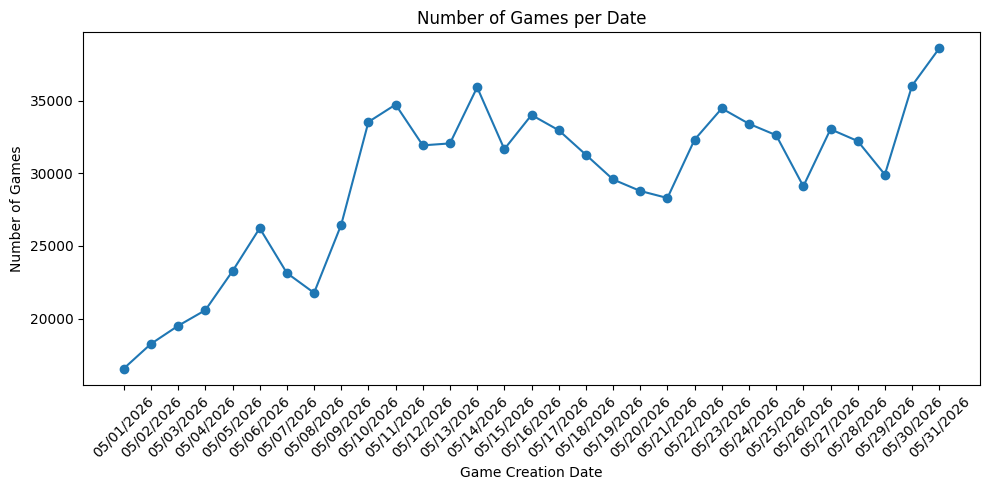

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(games_per_date["gameCreationDate"], games_per_date["n_games"], marker="o")
plt.title("Number of Games per Date")
plt.xlabel("Game Creation Date")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Distributions

### Game Duration

`gameDuration` measures how long the match lasted, in seconds.

We use `gameDuration` only for exploratory analysis. We are looking for unusually short or unusually long games, distribution shape, and possible data quality issues.

Questions this section helps answer:

- What is the typical match length?
- Are there extreme outliers?
- Are there suspiciously short games that may indicate remakes, early surrenders, or unusual records?
- Does the distribution look reasonable for League of Legends matches?
- Why would this variable be leakage if used as a pre-game feature?

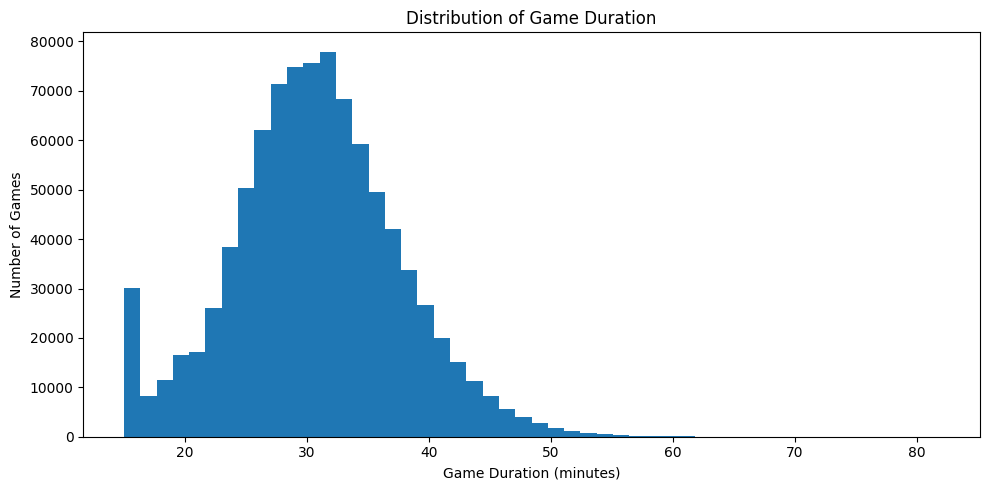

In [22]:
first_rows["gameDuration_min"] = first_rows["gameDuration"] / 60

plt.figure(figsize=(10, 5))
plt.hist(first_rows["gameDuration_min"], bins=50)
plt.title("Distribution of Game Duration")
plt.xlabel("Game Duration (minutes)")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

### League Points

`leaguePoints` is a player-level measure related to ranked skill. In this dataset, each player row has a league points value, and each game also has an `average_leaguePoints` value summarizing the match.

This variable is important because match outcome may depend partly on player skill. In this section, we examine the distribution of player league points to understand the skill range represented in the dataset.

Questions this section helps answer:

- What skill levels are represented in the data?
- Is the dataset concentrated around certain LP ranges?
- Are there unusual or extreme LP values?
- Do league points vary meaningfully across players or tiers?
- Would team-level LP differences be useful to explore later?

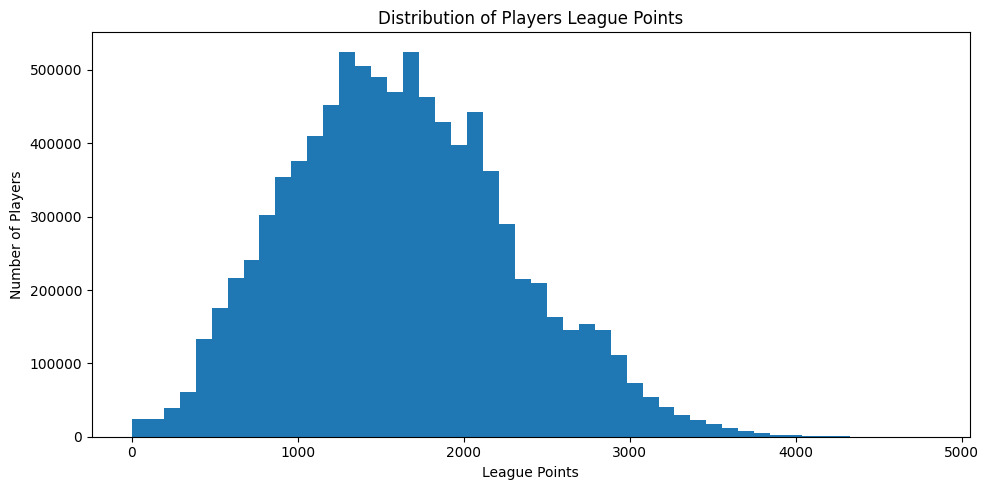

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(thin_df["leaguePoints"], bins=50)
plt.title("Distribution of Players League Points")
plt.xlabel("League Points")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.show()

Table `thin_df` has one row per player-game, not one row per player. That means a player who appears in 40 games contributes 40 league point values to the histogram, while a player who appears once contributes only one value.

As a result, the original histogram shows the distribution of player-game league point records, not the distribution of players.

To describe the distribution of league points across unique players, we will take the average of `leaguePoints`, aggregated by `puuid`

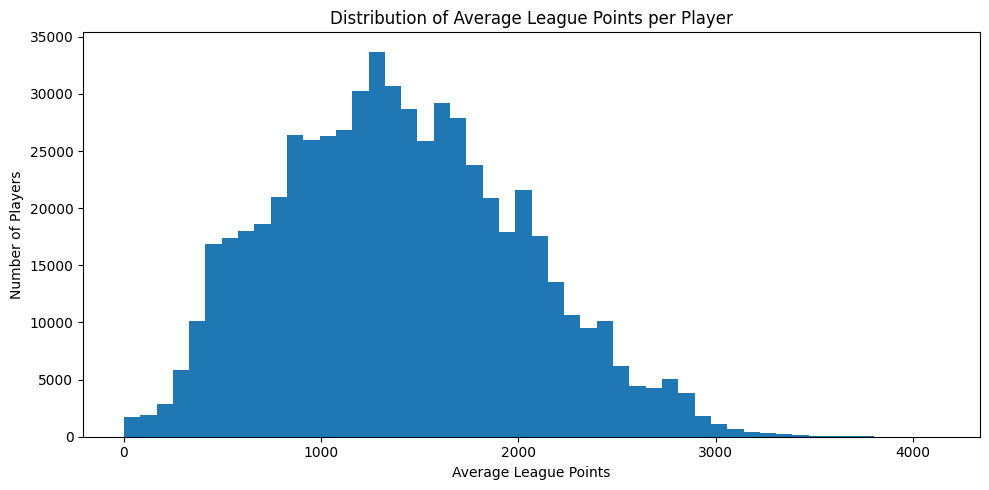

In [24]:
player_avg_lp = (
    thin_df
    .groupby("puuid", as_index=False)
    .agg(avg_leaguePoints=("leaguePoints", "mean"),
         n_games=("gameId", "nunique"))
)

plt.figure(figsize=(10, 5))
plt.hist(player_avg_lp["avg_leaguePoints"], bins=50)
plt.title("Distribution of Average League Points per Player")
plt.xlabel("Average League Points")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.show()

### Mastery Points

`mpoints` represents a player's mastery points on the champion they selected for that match. This is a player-champion measure: it tells us something about how much experience a player appears to have on that specific champion.

This variable is useful because champion familiarity may affect match outcome.

Questions this section helps answer:

- How skewed are mastery points?
- How many players are using champions with very low mastery?
- Are there players with extremely high mastery values?
- Does a log transformation make the distribution easier to understand?
- Could champion mastery become a useful feature later?

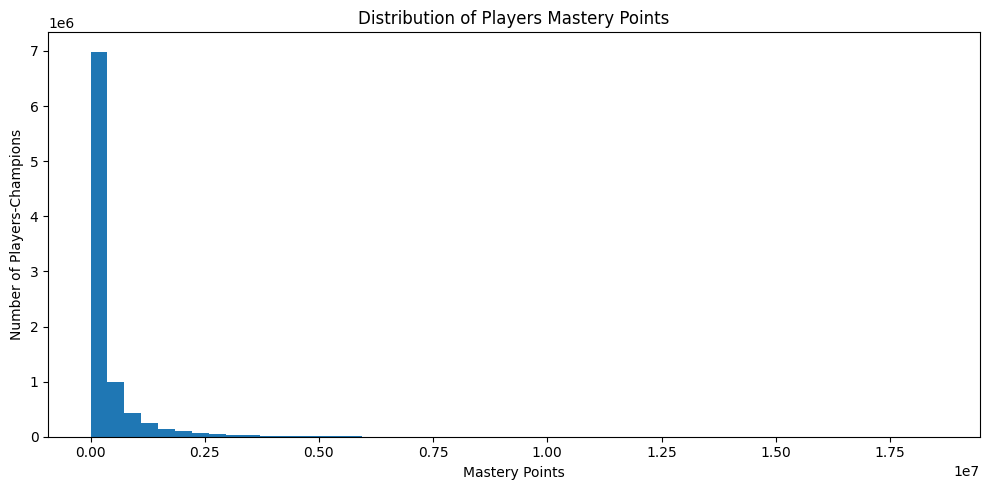

In [25]:
plt.figure(figsize=(10, 5))
plt.hist(thin_df["mpoints"], bins=50)
plt.title("Distribution of Players Mastery Points")
plt.xlabel("Mastery Points")
plt.ylabel("Number of Players-Champions")
plt.tight_layout()
plt.show()

The table `thin_df` has one row per player-game. That means the same player can appear many times, and the same player-champion combination can appear many times. For example, if one player uses the same champion in 20 matches, that player-champion pair contributes 20 mastery point values to the histogram.

As a result, the original histogram shows the distribution of player-game mastery point records, not the distribution of unique player-champion pairs.

Then A player who appears many times on the same champion can heavily influence the shape of the histogram. The y-axis label “Number of Player-Champions” is therefore misleading if we use `thin_df["mpoints"]` directly. The plot is really counting player-game rows.

To describe mastery across unique player-champion combinations, we first sort by time and keep the last record for each `puuid` and `championId` pair:

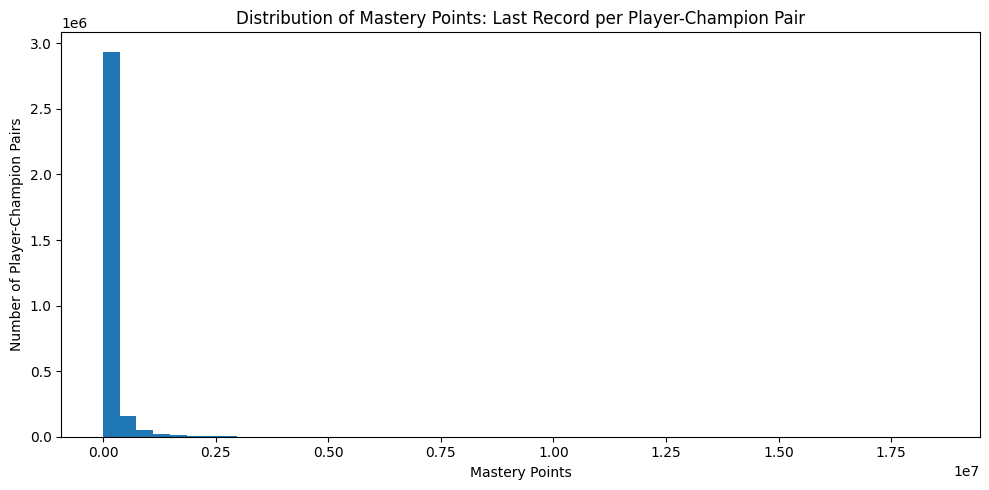

In [26]:
last_player_champion = (
    thin_df
    .sort_values("gameCreation")
    .drop_duplicates(subset=["puuid", "championId"], keep="last")
)

plt.figure(figsize=(10, 5))
plt.hist(last_player_champion["mpoints"], bins=50)
plt.title("Distribution of Mastery Points: Last Record per Player-Champion Pair")
plt.xlabel("Mastery Points")
plt.ylabel("Number of Player-Champion Pairs")
plt.tight_layout()
plt.show()

As we can see, mastery points are usually highly skewed. Many player-champion pairs have relatively low mastery, while a smaller number have extremely high mastery.

In the raw histogram, those very large values can stretch the x-axis and make most of the distribution hard to see.

To make the distribution easier to interpret, we apply a base-10 logarithmic transformation

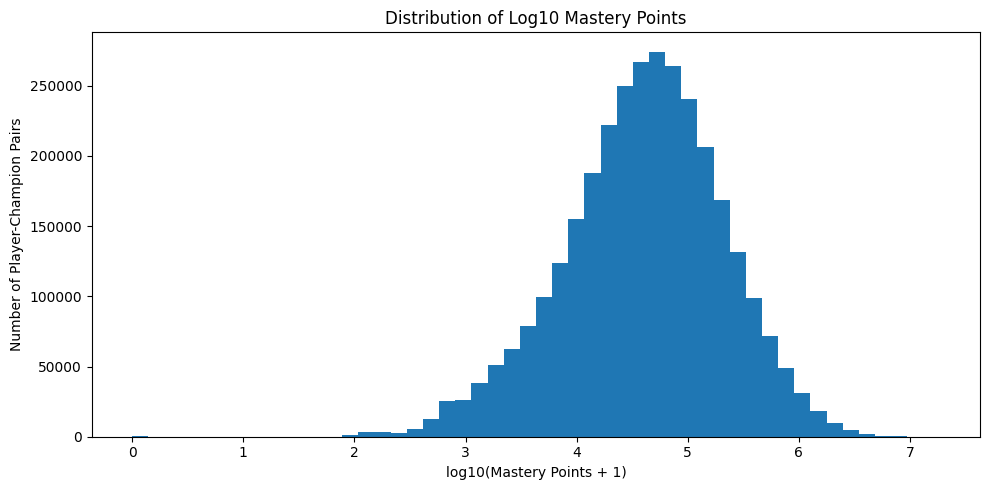

In [27]:
last_player_champion["log10_mpoints"] = np.log10(last_player_champion["mpoints"] + 1)

plt.figure(figsize=(10, 5))
plt.hist(last_player_champion["log10_mpoints"], bins=50)
plt.title("Distribution of Log10 Mastery Points")
plt.xlabel("log10(Mastery Points + 1)")
plt.ylabel("Number of Player-Champion Pairs")
plt.tight_layout()
plt.show()

## Correlation Analysis

Correlation helps us examine linear relationships between numeric variables.

There are several cautions to keep in mind:

1. **Correlation does not imply causation** (Ice cream sales are highly correlated with shark attacks!)
3. Player-level rows are not fully independent because each match appears multiple times in the thin table.
4. Identifier columns such as `championId` should not be treated as numeric variables. The number assigned to a champion is just a label, not a meaningful measurement.

For this project, the most useful correlations are not raw player-level correlations. Since the outcome is decided at the team level, it is more meaningful to compare the blue team to the red team and ask whether differences between the teams are related to the blue team winning. We will do that later

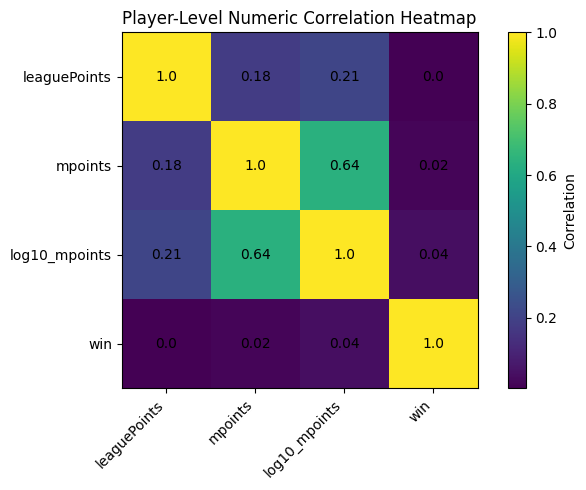

In [28]:
thin_corr = thin_df.copy()
thin_corr["log10_mpoints"] = np.log10(thin_corr["mpoints"] + 1)

player_corr_cols = [
    "leaguePoints",
    "mpoints",
    "log10_mpoints",
    "win"
]

corr = thin_corr[player_corr_cols].corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha="center", va="center")

plt.title("Player-Level Numeric Correlation Heatmap")
plt.tight_layout()
plt.show()

## Team-Level Summaries

The thin table has one row per player-game, but the outcome of a League of Legends match is team-level: either the blue team wins or the red team wins.

For that reason, we create team-level summaries before looking at relationships with the outcome. For each `gameId` and team, we summarize variables such as:

- average league points
- median league points
- average mastery points
- median mastery points

These summaries convert individual player information into team-level information. This better matches the structure of the prediction problem.

For example, the question is not simply:

> Do players with higher league points win more often?

A better question is:

> Does the blue team win more often when its average league points are higher than the red team's average league points?

This team-level view is closer to the kind of information a match outcome model would need.

In [29]:
team_summary = (
    thin_df
    .groupby(["gameId", "team"])
    .agg(
        team_avg_lp=("leaguePoints", "mean"),
        team_median_lp=("leaguePoints", "median"),
        team_avg_mpoints=("mpoints", "mean"),
        team_median_mpoints=("mpoints", "median")
    )
    .reset_index()
)

team_summary.head()

,gameId,team,team_avg_lp,team_median_lp,team_avg_mpoints,team_median_mpoints
0,5550784554,blue,1062.0,1054.0,104039.2,44613.0
1,5550784554,red,1086.8,1082.0,840304.4,171589.0
2,5550784663,blue,2288.4,2224.0,479982.8,87372.0
3,5550784663,red,2302.0,2316.0,227625.4,30274.0
4,5550784708,blue,1126.2,1158.0,473901.2,225770.0


In [30]:
team_wide = team_summary.pivot(
    index="gameId",
    columns="team",
    values=[
        "team_avg_lp",
        "team_median_lp",
        "team_avg_mpoints",
        "team_median_mpoints"
    ]
)

team_wide.columns = [
    f"{metric}_{team}" for metric, team in team_wide.columns
]

team_wide = team_wide.reset_index()

team_wide.head()

,gameId,team_avg_lp_blue,team_avg_lp_red,team_median_lp_blue,team_median_lp_red,team_avg_mpoints_blue,team_avg_mpoints_red,team_median_mpoints_blue,team_median_mpoints_red
0,5550784554,1062.0,1086.8,1054.0,1082.0,104039.2,840304.4,44613.0,171589.0
1,5550784663,2288.4,2302.0,2224.0,2316.0,479982.8,227625.4,87372.0,30274.0
2,5550784708,1126.2,1049.4,1158.0,957.0,473901.2,66974.0,225770.0,84407.0
3,5550785582,429.2,478.6,607.0,458.0,384572.4,39072.6,26655.0,31140.0
4,5550785626,1679.4,1888.0,1788.0,1891.0,665848.0,224235.2,220614.0,79118.0


In [31]:
first_rows = (
    thin_df
    .groupby("gameId")
    .first()
    .reset_index()[["gameId", "patch", "tier", "win"]]
    .rename(columns={"win": "bwin"})
)

game_team = first_rows.merge(team_wide, on="gameId", how="left")

game_team["blue_minus_red_avg_lp"] = (
    game_team["team_avg_lp_blue"] - game_team["team_avg_lp_red"]
)

game_team["blue_minus_red_median_lp"] = (
    game_team["team_median_lp_blue"] - game_team["team_median_lp_red"]
)

game_team["blue_minus_red_avg_mpoints"] = (
    game_team["team_avg_mpoints_blue"] - game_team["team_avg_mpoints_red"]
)

game_team["blue_minus_red_median_mpoints"] = (
    game_team["team_median_mpoints_blue"] - game_team["team_median_mpoints_red"]
)

game_team.head()

,gameId,patch,tier,bwin,team_avg_lp_blue,team_avg_lp_red,team_median_lp_blue,team_median_lp_red,team_avg_mpoints_blue,team_avg_mpoints_red,team_median_mpoints_blue,team_median_mpoints_red,blue_minus_red_avg_lp,blue_minus_red_median_lp,blue_minus_red_avg_mpoints,blue_minus_red_median_mpoints
0,5550784554,169,Silver II,0,1062.0,1086.8,1054.0,1082.0,104039.2,840304.4,44613.0,171589.0,-24.8,-28.0,-736265.2,-126976.0
1,5550784663,169,Platinum II,1,2288.4,2302.0,2224.0,2316.0,479982.8,227625.4,87372.0,30274.0,-13.6,-92.0,252357.4,57098.0
2,5550784708,169,Silver II,1,1126.2,1049.4,1158.0,957.0,473901.2,66974.0,225770.0,84407.0,76.8,201.0,406927.2,141363.0
3,5550785582,169,Bronze IV,0,429.2,478.6,607.0,458.0,384572.4,39072.6,26655.0,31140.0,-49.4,149.0,345499.8,-4485.0
4,5550785626,169,Emerald III,0,1679.4,1888.0,1788.0,1891.0,665848.0,224235.2,220614.0,79118.0,-208.6,-103.0,441612.8,141496.0


## Team Differences: Blue Minus Red

After creating team-level summaries, we compute differences between the blue team and the red team.

For example:

```text
blue_minus_red_avg_lp = blue team average LP - red team average LP

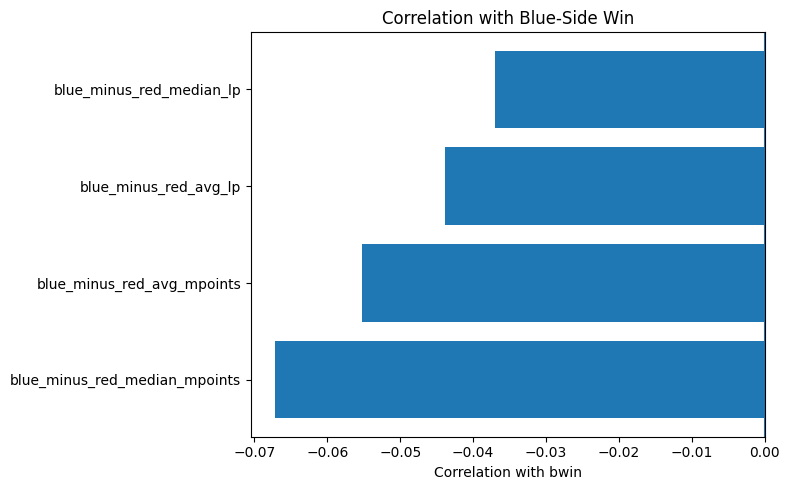

In [32]:
corr_with_bwin = (
    game_team[
        [
            "blue_minus_red_avg_lp",
            "blue_minus_red_median_lp",
            "blue_minus_red_avg_mpoints",
            "blue_minus_red_median_mpoints",
            "bwin"
        ]
    ]
    .corr()["bwin"]
    .drop("bwin")
    .sort_values()
)

plt.figure(figsize=(8, 5))
plt.barh(corr_with_bwin.index, corr_with_bwin.values)
plt.axvline(0)
plt.title("Correlation with Blue-Side Win")
plt.xlabel("Correlation with bwin")
plt.tight_layout()
plt.show()

# Week 2 Assignment: Data Leakage Audit

In this notebook, we explored the League of Legends dataset before building features or training a model. We looked at game-level structure, player-level distributions, grouped win rates, mastery points, team-level summaries, and correlations with blue-side wins.

The assignment for this week focuses on one central MLOps issue: **data leakage**.

A summary can be valid for exploratory analysis and still be invalid as a model feature. For example, `gameDuration` is useful for understanding match length, but it is not available before the match starts. A full-dataset champion win rate may help us understand the dataset, but it would leak future outcomes if used to predict earlier games.

Your task is to audit possible features and decide which ones would be safe for a pre-game match outcome model.

## What You Will Do

Submit this assignment as the final section of your Week 2 notebook.

1. **Define prediction time**  
   Explain when the model is making its prediction. What information is available before the match starts? What information is not available yet?

2. **Create a leakage audit table**  
   List possible model features or EDA summaries, such as `leaguePoints`, `mpoints`, `gameDuration`, champion win rate, player win rate, and team-level LP differences. For each one, decide whether it would be known before the match starts, whether it depends on win/loss outcomes, whether it accidentally uses future games, and whether it is safe to use in a pre-game prediction model.

3. **Explain three leakage risks**  
   Choose three unsafe or conditionally unsafe features. Explain why they look useful, why they leak information, and how they could inflate model performance.

4. **Rewrite leaky ideas as safe features**  
   Take three risky features and redesign them so they only use information available before the match. For example, a full-dataset player win rate could become a prior player win rate computed only from games before the current match.

5. **Plan features for Week 3**  
   Propose several features you may build next week, such as recent win rate, player-champion win rate, role consistency, champion pool size, streaks, or team-level differences. For each one, explain how you would compute it without leakage.

6. **Support your reasoning with evidence**  
   Include at least three plots or summary tables that support your leakage audit or your Week 3 feature plan. Each one should help answer one of the following questions:

   - Does this feature appear potentially useful?
   - Would this feature be available before the match starts?
   - Does this summary depend on future outcomes?
   - Is there enough historical data to compute this feature safely?
   - Does the pattern vary across time, patch, tier, or sample size?

   For each plot or table, write 2–4 sentences explaining what it shows and how it affects your decision about whether the feature is safe.

## Key Question

By the end of this assignment, you should be able to answer:

> What is the difference between a valid EDA summary and a valid model feature?

This distinction is central to MLOps. In production, a model can only use information that would actually be available at prediction time.

# Assignment 2 — Data Leakage Audit

## Your prediction-time definition
I am going to set my prediction time at the pre-match point where champions have been selected but the actual game has not started.

At this point we know the players, roles, champions, team color, patch, ranks, champion mastery, and historical performance.

We do not know any performance metrics for the current match or any related attributes. These include outcome, duration etc.

The business use case is a wagering-support product: we provide predictions that customers could use when deciding whether to place bets on match outcomes. I recognize that, in a real deployment, there may be only a small window between champion selection and match start. The data may not always be available quickly enough to generate a prediction, deliver it to customers, and allow them to place a bet before the market closes. For this assignment, I assume that the post-champion-selection data is available in time.
    
I chose the post-champion-selection prediction point because it provides more meaningful pre-match information than an earlier prediction point. In particular, selected champions and team composition may help estimate match outcome beyond what is known from player rank or historical performance alone. This prediction point is still before the game begins, so the model must exclude all current-match and post-match information and must compute historical features only from data available before the match.

## Your leakage audit table

| Feature or Summary | Known Before Match? | Uses Win/Loss Outcomes? | Uses Future Games? | Safe for Pre-Game Model? | Explanation |
|:-------------------|:--------------------|:------------------------|:-------------------|:-------------------------|:------------|
| `leaguePoints` |Yes|No|No|Yes|Use only pre-match values  |
| `mpoints` |Yes|No|No|Yes|Mastery points for the selected champion since my prediction point is after the selection point but before match start |
| `gameDuration` |No|No|No|No|This value is available only after the match ends so is not available for prediction|
|Prior player-champion win rate |Yes|Yes|No|Yes|Calculate win rate for this player with selected champion; requires proper calculation using only historical matches  |
|Prior player win rate |Yes|Yes|No|Yes|Requires proper calculation using only historical matches  |
|Team-level LP differences |Yes|No|No|Yes|Computed as player team average LP - opposing team average LP |
|Full data set player win rate|No|Yes|Yes| No|Not a good calculation as written to fix limit calculation to only historical matches from the perspective of the current record|
|Prior patch side win rate|Yes|Yes|No|Yes| For each patch, calculate blue-side or red-side win rate using only earlier matches in that patch|
|Team prior champion average win rate |Yes|Yes|No| Yes | For all players on the team average the prior champion win rate on their selected champion|
|Recent player win rate |Yes|Yes|No|Yes| Take the last n games and calculate the win rate. Propose n=10 but will explore options|
|Team average mpoints differential|Yes|No|No|Yes| Calculate average mpoints for each team then calculate difference. |







Because the dataset is player-match-level, validation should split by match ID, not by player row. If rows from the same match appear in both train and test, the model can indirectly learn match-level information from duplicated context.

## Three leakage-risk explanations
**gameDuration** - This feature is fully unsafe in any reasonable implementation. There is tehoretical predictive power if a particular player tends to do better in long, grinding matches vs. shorter intense games but this is a match level feature that isn't known until the conclusion. There isn't a logical way to make this feature not leak because even if calculated historically using for example historical performance in long matches we wouldn't know if the subject match we are predicting would be long. So even if we contrive a feature that doesn't leak it would have little or no predictive value.

**Team champion average win rate** - This is one of my favorites. If calculated using the entire dataset then a given record on May 25th would include win results for subsequent days (the future from the perspeective of the record). Thus the future would be leaking into historical records. Even if we limited the aggregation to the training set, future (for the subject record) results would corrupt the predictive value of the feature. We would avoid this by including only prior match results for any given player-match record. The unsafe version is not the idea of champion win rate; it is the full-dataset calculation. The safe version is an as-of calculation.

**Prior patch side win rate** - This feature is intended to detect whether a particular patch has created an unexpected side advantage, such as blue side or red side performing unusually well. This is probably uncommon, but if Riot Games releases an unbalanced patch, the side-specific win rate could create a useful wagering signal. The first design risk is failing to isolate by patch. If older patches are included, the feature may dilute or hide the current patch signal because it mixes different game versions, although this is more of a feature-quality problem than leakage. The leakage risk comes from calculating the patch-side win rate using matches that occur after the current record. To avoid this, the feature should use only earlier matches from the same patch. Otherwise, future results from the current patch would be included, making the feature less valid for production and potentially overstating performance during validation.

## Three safe feature rewrites
**leaguePoints** - this is a trivial example. I included it here as an example of a bulletproof feature but only from the perspective of leakage. Since our data is at match level we are given the league points of the team before match start. It is inherently insulated from leakage. Note that I don't anticipate a lot of predictive value as a scalar value without something to compare it against - for example the other team's league points, doesn't provide a lot of information.

**gameDuration** - the opposite of leaguePoints from a leakage perspective. This one can't be made safe and have predictive value. All we would know is how players perform in games of a given length but the parameter would have no value in the model because we would not know the respective input value until after the subject match is complete.

**Full data set player win rate** - if not constrained to just prior matches this leaks eggregiously. Depending on how eggregious it would include validation and test data as well as generally corrupting the model with future training data. This thoroughly sets up a model to fail catastrophically in production. We fix it with Prior player win rate which constrains the aggregation to events that occured prior to the subject record.

**Recent player win rate** - there doesn't appear to be much chance for leakage as this is defined. Simply take the most recent n matches and calculate the win rate. There is potential leakage if the implementation is improper, specifically around the beginning of the dataset or of a players individual dataset. If there are not n prior games and we substitute this with the first n events then we would be leaking future data into the subject records calculation. To prevent this we need to come up with a valid strategy for handling missing or insufficient data on the right side. Perhaps setting the value to zero or using only the available data for the calculation.

## At least three planned Week 3 features
**Prior patch side win rate** - As mentioned above, here I'm fishing for bugs or unintentional bias in the code of a particular patch. It's not likely to hit often or for very long but if it ever does occur then there will be a temporary outsized betting opportunity for our customers. This is calculated at the patch, match, side grain. I would also test this with other combinations of attributes like champion and lane to see if a patch has more subtle impacts to specific attributes. This would be a simple win rate for the players side based on grouping by the included attributes.

**Champion pick comfort measure** - Calculate the percent of last n matches that a player has picked this champion. Possibly aggregate this across the entire team with mean. If a player is playing a champion that they've used a lot recently we can assume better proficiency. Use only prior matches and pick a recent number for n to include only the most recent ones. Perhaps even weight it by recency. That would be particularly interesting. This is a player level metric unless aggregated across the team.

**Direct player matchup win percentage** - Win percentage of a given player against their direct opponent as determined by being in the same lane on previous matches. Use only prior matches relative to the subject match. If a given player usually dominates their direct opponent this could represent an advantage. This is player level.

**Team cohesion** - Number of times that this exact team has played together. Five buddies who always play together might be generally dominant due to familiarity and good communication. Include only prior matches. This is a team level feature.

**Team win percentage** - Similar to team cohesion but calculate the historical win percentage over prior matches for this exact team. They might be extraordinarily bad or good. This is a team level feature.

For these last two features I will examine the occurrence. In this dataset I'm not sure if we have randomly assigned teams or if folks can form their own teams. If it's random then the data will be quite sparse and I could lower the threshold to pairs (how many times the given pair has played together or win percentage).


In [34]:
champ_wr = thin_df[['gameId', 'gameCreationDate', 'championId', 'win']].copy()
champ_wr['gameCreationDate'] = pd.to_datetime(champ_wr['gameCreationDate'], format='%m/%d/%Y')
champ_wr = champ_wr.sort_values(['gameCreationDate', 'gameId', 'championId']).copy()

# Prior-only cumulative stats by champion.
# shift/cumcount make sure the current match result is NOT included.
g = champ_wr.groupby('championId', group_keys=False)

champ_wr['prior_champion_games'] = g.cumcount()
champ_wr['prior_champion_wins'] = g['win'].cumsum().groupby(champ_wr['championId']).shift(1)

champ_wr['prior_champion_win_rate'] = (
    champ_wr['prior_champion_wins'] / champ_wr['prior_champion_games']
    )

# Optional smoothed version to avoid overreacting to tiny samples.
# k acts like k prior games at baseline/global win rate.
global_win_rate = champ_wr['win'].mean()
k = 20

champ_wr['prior_champion_win_rate_smoothed'] = (
    champ_wr['prior_champion_wins'].fillna(0) + global_win_rate * k
) / (
    champ_wr['prior_champion_games'] + k
)

# Current-including historical value, for comparison.
# This is useful as a leakage demonstration.
champ_wr['current_including_champion_win_rate'] = (
    g['win'].cumsum() / (g.cumcount() + 1)
    )

print("Sample prior champion win-rate feature:")
display(
    champ_wr[
        ['gameId', 'gameCreationDate', 'championId', 'win',
         'prior_champion_games', 'prior_champion_win_rate',
         'prior_champion_win_rate_smoothed',
         'current_including_champion_win_rate']
    ].head(15)
)


Sample prior champion win-rate feature:


,gameId,gameCreationDate,championId,win,prior_champion_games,prior_champion_win_rate,prior_champion_win_rate_smoothed,current_including_champion_win_rate
5617659,5550784554,2026-05-01,19,0,0,NaN,0.5,0.0
7442171,5550784554,2026-05-01,21,0,0,NaN,0.5,0.0
144123,5550784554,2026-05-01,23,1,0,NaN,0.5,1.0
2880891,5550784554,2026-05-01,29,1,0,NaN,0.5,1.0
4705403,5550784554,2026-05-01,39,0,0,NaN,0.5,0.0
1056379,5550784554,2026-05-01,102,1,0,NaN,0.5,1.0
3793147,5550784554,2026-05-01,111,1,0,NaN,0.5,1.0
1968635,5550784554,2026-05-01,163,1,0,NaN,0.5,1.0
6529915,5550784554,2026-05-01,777,0,0,NaN,0.5,0.0
8354427,5550784554,2026-05-01,800,0,0,NaN,0.5,0.0


## Support Reasoning with Evidence

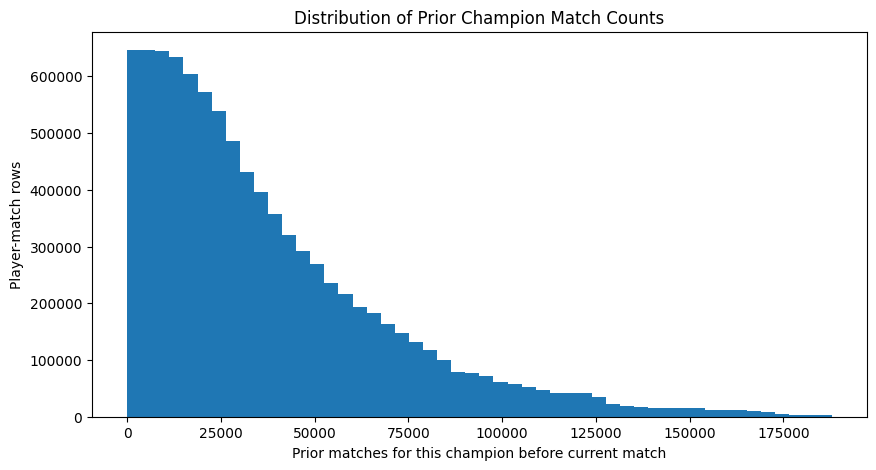

count    9.122560e+06
mean     3.747165e+04
std      3.243071e+04
min      0.000000e+00
10%      5.303000e+03
25%      1.329900e+04
50%      2.834800e+04
75%      5.260200e+04
90%      8.196100e+04
max      1.878870e+05
Name: prior_champion_games, dtype: float64


In [37]:
# Plot 1: Distribution of prior champion history counts

plt.figure(figsize=(10, 5))
plt.hist(champ_wr['prior_champion_games'], bins=50)
plt.title('Distribution of Prior Champion Match Counts')
plt.xlabel('Prior matches for this champion before current match')
plt.ylabel('Player-match rows')
plt.show()

print(
    champ_wr['prior_champion_games'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
)

### Plot 1 Discussion
This plot demonstrates that there is certainly enough historical data to support using prior champion performance as a feature. There is also evidence that many records are lacking a lot of history (the left hand side of the plot). This is likely due to early records and/or less popular champions reinforcing a need to further lookin into smoothing.

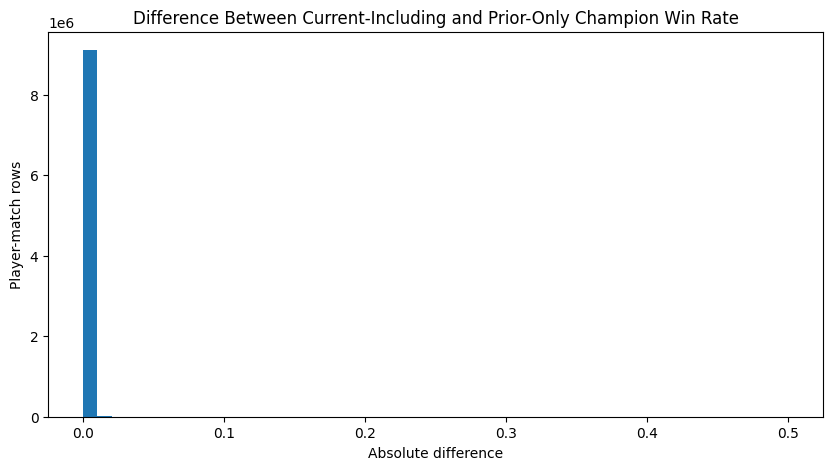

Difference summary:


,abs_diff_current_vs_prior_smoothed
count,9.122560e+06
mean,1.405053e-04
std,3.720274e-03
min,0.000000e+00
50%,1.672971e-05
75%,3.781332e-05
90%,9.722758e-05
95%,1.950647e-04
max,5.000000e-01


In [38]:
# Plot 2: Leakage demonstration — current-including vs prior-only

champ_wr['abs_diff_current_vs_prior_smoothed'] = (
    champ_wr['current_including_champion_win_rate']
    - champ_wr['prior_champion_win_rate_smoothed']
).abs()

plt.figure(figsize=(10, 5))
plt.hist(champ_wr['abs_diff_current_vs_prior_smoothed'].dropna(), bins=50)
plt.title('Difference Between Current-Including and Prior-Only Champion Win Rate')
plt.xlabel('Absolute difference')
plt.ylabel('Player-match rows')
plt.show()

print("Difference summary:")
display(
    champ_wr['abs_diff_current_vs_prior_smoothed']
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95])
)

### Plot 2 Discussion
Leakage was a challenge for me to show on a plot but I wanted to give it a shot. This plot shows that there is a difference between the win rate including the current game and the prior-only win rate. Any difference indicates that leakage would have an impact. For champions with lots of history this impact would be minimal but we want to avoid leakage on principle.

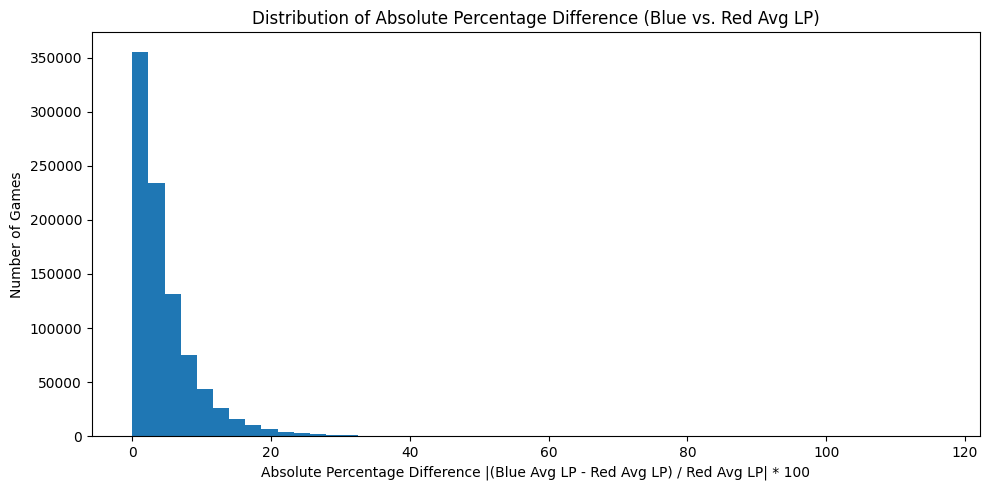

Descriptive statistics for Absolute Blue Minus Red Average League Points (Percentage Difference):


,blue_minus_red_avg_lp_percent_diff
count,912256.000000
mean,4.656515
std,4.907782
min,0.000000
10%,0.557131
25%,1.424761
50%,3.171222
75%,6.186441
90%,10.499880
max,116.348774


In [43]:
# Plot 3: League points differential percentage

game_team['blue_minus_red_avg_lp_percent_diff'] = (
    (game_team['team_avg_lp_blue'] - game_team['team_avg_lp_red']) /
    game_team['team_avg_lp_red']
).abs() * 100

plt.figure(figsize=(10, 5))
plt.hist(game_team['blue_minus_red_avg_lp_percent_diff'].dropna(), bins=50)
plt.title('Distribution of Absolute Percentage Difference (Blue vs. Red Avg LP)')
plt.xlabel('Absolute Percentage Difference |(Blue Avg LP - Red Avg LP) / Red Avg LP| * 100')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.show()

print("Descriptive statistics for Absolute Blue Minus Red Average League Points (Percentage Difference):")
display(game_team['blue_minus_red_avg_lp_percent_diff'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

### Plot 3 Discussion
Remember our business case. We're trying to give our customers who are wagering on LoL games a better chance of winning their bets.

There's obvious signal value in the league points differentials. In our business case the larger differential matches are probably obvious so if we're trying to predict winners better than the line then we'd probably avoid those. We're looking for matches with low obvious signal value. For strict prediction I'll consider bucketing these.